In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [135]:
df = pd.read_csv("PREPROCESSED.csv")
speakers_df = pd.read_csv("speakers_enhanced_for_model.csv")

df = df[
    (df['type'] != 'TED-Ed Original') & 
    (df['type'] != 'Original Content') & 
    (df['type'] != 'Podcast (audio only)') & 
    (df['type'] != 'Custom sponsored content') &
    (df['type'] != 'Best of Web')
]
print(df.shape)

# Variable cible
y = df['is_viral'].copy()
print(y.shape)

(5338, 26)
(5338,)


In [136]:
import re
from collections import defaultdict

# --- MAIN SPEAKER ---
def extract_main_speaker(s):
    if pd.isna(s):
        return None
    s = s.lower().strip()
    s = re.sub(r'\s*(and|&|\+|,)\s*', '|', s)
    speakers = s.split('|')
    return speakers[0].strip()

df['main_speaker'] = df['speakers'].apply(extract_main_speaker)

speakers_df['speaker'] = speakers_df['speaker'].str.lower().str.strip()

# --- TOPIC TO CATEGORY DICT ---
topic_to_category = {}
for category, topics in topic_categories.items():
    for topic in topics:
        topic_to_category[topic.lower()] = category

# --- CALCULATE VIRAL RATE PER TOPIC ---
topic_counts = defaultdict(int)
topic_viral_counts = defaultdict(int)

for _, row in df.iterrows():
    topics = [t.strip().lower() for t in row['topics'].strip('"').split(',')]
    for t in topics:
        topic_counts[t] += 1
        if row['is_viral']:
            topic_viral_counts[t] += 1

topic_viral_rates = {t: (topic_viral_counts[t] / topic_counts[t]) * 100 for t in topic_counts}

# --- VIDEO TOPIC FEATURES ---
HIGH_VIRAL_THRESHOLD = 20  # topics with >20% viral rate

def process_video_topics(topics_str):
    topics = [t.strip().lower() for t in topics_str.strip('"').split(',')]
    
    # Map to broad categories
    categories = set()
    for t in topics:
        if t in topic_to_category:
            categories.add(topic_to_category[t])
    
    num_categories = len(categories)
    topic_cohesion = 1 / num_categories if num_categories > 0 else 0
    has_high_viral_topic = int(any(topic_viral_rates.get(t, 0) > HIGH_VIRAL_THRESHOLD for t in topics))
    
    return {
        'num_categories': num_categories,
        'topic_cohesion': topic_cohesion,
        'has_high_viral_topic': has_high_viral_topic
    }

# Apply to df
video_features = df['topics'].apply(process_video_topics)
df['num_categories'] = video_features.apply(lambda x: x['num_categories'])
df['topic_cohesion'] = video_features.apply(lambda x: x['topic_cohesion'])
df['has_high_viral_topic'] = video_features.apply(lambda x: x['has_high_viral_topic'])

# --- BROAD CATEGORIES LIST ---
df['broad_categories'] = df['topics'].apply(lambda s: [topic_to_category[t.strip().lower()] for t in s.strip('"').split(',') if t.strip().lower() in topic_to_category])

# --- PEAK MONTH ---
df['published_at'] = pd.to_datetime(df['published_at'])
df['year'] = df['published_at'].dt.year
df['month'] = df['published_at'].dt.month

peak_months = df.groupby('year').apply(lambda g: g.groupby('month')['is_viral'].sum().idxmax()).to_dict()
df['is_peak_month'] = df.apply(lambda row: int(peak_months.get(row['year'], 0) == row['month']), axis=1)

print("✅ Added features: num_categories, topic_cohesion, has_high_viral_topic, broad_categories, is_peak_month")


✅ Added features: num_categories, topic_cohesion, has_high_viral_topic, broad_categories, is_peak_month


In [137]:
print("ÉTAPE 1: Modèle baseline avec features brutes")

df_model = df.copy()
speakers_model = speakers_df.copy()

# Remove target variables
features_to_drop = ['views', 'popularity_score', 'is_viral_top5', 'days_since_published']
df_model = df_model.drop(columns=[col for col in features_to_drop if col in df_model.columns])

# Target variable
y = df['is_viral'].copy()

# Extracting features 
# Numeric Features
numeric_features = [
    'duration_minutes',
    'number_of_topics',
    'transcript_length',
    'topic_cohesion',
    'num_categories',
    'has_high_viral_topic',
    'is_peak_month'
]



X_numeric = df_model[[col for col in numeric_features if col in df_model.columns]].copy()

# Categorical Features
# print("3. Extraction des features catégorielles...")

categorical_features = [
    'type',
    'video_context', 
    'content_category'
]

# Encoder les catégorielles
X_categorical = pd.DataFrame(index=df_model.index)
for col in [c for c in categorical_features if c in df_model.columns]:
    le = LabelEncoder()
    X_categorical[col] = le.fit_transform(df_model[col].fillna('Unknown'))



# Speaker Features
speaker_features_to_use = [
    'videos',
    'average_popularity_score',
    'viral_rate',
    'wikipedia_numeric',
    'comprehensive_popularity_score'
]

# Merge with df
speaker_features = [
    'videos',
    'average_popularity_score',
    'viral_rate',
    'wikipedia_numeric',
    'comprehensive_popularity_score'
]

print(df_model.shape)
df_model = df_model.merge(
    speakers_model[['speaker'] + speaker_features],
    how='left',
    left_on='main_speaker',
    right_on='speaker'
)
print
df_model = df_model.rename(columns={
    'videos': 'speaker_videos',
    'wikipedia_numeric': 'speaker_has_wikipedia_page'
})

df_model['speaker_videos'] = df_model['speaker_videos'].fillna(0)
df_model['speaker_has_wikipedia_page'] = (
    df_model['speaker_has_wikipedia_page']
    .fillna(0)
    .astype(int)
)
print(df_model.shape)
# Nettoyage colonnes en double
df_model = df_model.drop(columns=['speaker_y'], errors='ignore')
df_model = df_model.rename(columns={'speaker_x': 'speaker'})


# Ajouter au X_numeric
for feature in speaker_features_to_use:
    col_name = f'speaker_{feature}'
    if col_name in df_model.columns:
        X_numeric[col_name] = df_model[col_name].fillna(0)

# Combiner toutes les features
print("5. Combinaison des features...")

X = pd.concat([X_numeric, X_categorical], axis=1)



# Remplir les NaN
X = X.fillna(0)

print(f"✓ Shape final: {X.shape}")
print(f"✓ Features utilisées: {list(X.columns)}")

# Split train/test
print("\n6. Split train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"  Train: {X_train.shape}, {y_train.mean():.1%} viral")
print(f"  Test:  {X_test.shape}, {y_test.mean():.1%} viral")

# 7. Modèle simple
print("\n7. Entraînement modèle...")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Trying with Logistic Regression and Random Forest
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f"\n  {name}...")
    
    # Entraîner
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Stats
    accuracy = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"    Accuracy: {accuracy:.3f}")
    print(f"    AUC: {auc:.3f}")

# 8. Feature importance (Random Forest)
print("\n8. Importance des features (Random Forest)...")
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features les plus importantes:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:30} {row['importance']:.4f}")

# 9. Best model
print("\n9. Évaluation détaillée...")
best_model_name = max(results.items(), key=lambda x: x[1]['auc'])[0]
best_result = results[best_model_name]

print(f"\nMeilleur modèle: {best_model_name}")
print(f"AUC: {best_result['auc']:.3f}")
print(f"Accuracy: {best_result['accuracy']:.3f}")

# Rapport de classification
print("\nRapport de classification:")
print(classification_report(y_test, best_result['y_pred']))

# Baseline naïve
print("\n10. Baseline naïve (toujours prédire la classe majoritaire):")
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print(f"  Accuracy baseline: {baseline_accuracy:.3f}")
print(f"  Amélioration: {best_result['accuracy'] - baseline_accuracy:+.3f}")



ÉTAPE 1: Modèle baseline avec features brutes
(5338, 30)
(5344, 36)
5. Combinaison des features...
✓ Shape final: (5338, 11)
✓ Features utilisées: ['duration_minutes', 'number_of_topics', 'transcript_length', 'topic_cohesion', 'num_categories', 'has_high_viral_topic', 'is_peak_month', 'speaker_videos', 'type', 'video_context', 'content_category']

6. Split train/test...
  Train: (3736, 11), 5.6% viral
  Test:  (1602, 11), 5.6% viral

7. Entraînement modèle...

  Logistic Regression...
    Accuracy: 0.948
    AUC: 0.732

  Random Forest...
    Accuracy: 0.949
    AUC: 0.756

8. Importance des features (Random Forest)...

Top 10 features les plus importantes:
  transcript_length              0.2585
  video_context                  0.2380
  duration_minutes               0.1311
  number_of_topics               0.1129
  speaker_videos                 0.0548
  num_categories                 0.0544
  topic_cohesion                 0.0534
  has_high_viral_topic           0.0460
  is_peak_mont

In [138]:
y_pred_lr = results['Logistic Regression']['y_pred']
y_pred_proba_lr = results['Logistic Regression']['y_pred_proba']

df_test_lr = X_test.copy()
df_test_lr['y_true'] = y_test
df_test_lr['y_pred'] = y_pred_lr
df_test_lr['y_proba'] = y_pred_proba_lr

fp_lr = df_test_lr[(df_test_lr['y_true']==0) & (df_test_lr['y_pred']==1)]
fn_lr = df_test_lr[(df_test_lr['y_true']==1) & (df_test_lr['y_pred']==0)]
tp_lr = df_test_lr[(df_test_lr['y_true']==1) & (df_test_lr['y_pred']==1)]
tn_lr = df_test_lr[(df_test_lr['y_true']==0) & (df_test_lr['y_pred']==0)]

print("Logistic Regression -> FP:", len(fp_lr), "FN:", len(fn_lr), "TP:", len(tp_lr), "TN:", len(tn_lr))


Logistic Regression -> FP: 3 FN: 81 TP: 9 TN: 1509


In [139]:
y_pred_lr = results['Random Forest']['y_pred']
y_pred_proba_lr = results['Random Forest']['y_pred_proba']

df_test_lr = X_test.copy()
df_test_lr['y_true'] = y_test
df_test_lr['y_pred'] = y_pred_lr
df_test_lr['y_proba'] = y_pred_proba_lr

fp_lr = df_test_lr[(df_test_lr['y_true']==0) & (df_test_lr['y_pred']==1)]
fn_lr = df_test_lr[(df_test_lr['y_true']==1) & (df_test_lr['y_pred']==0)]
tp_lr = df_test_lr[(df_test_lr['y_true']==1) & (df_test_lr['y_pred']==1)]
tn_lr = df_test_lr[(df_test_lr['y_true']==0) & (df_test_lr['y_pred']==0)]

print("Random Forest -> FP:", len(fp_lr), "FN:", len(fn_lr), "TP:", len(tp_lr), "TN:", len(tn_lr))


Random Forest -> FP: 4 FN: 78 TP: 12 TN: 1508


2. Extraction des features numériques...
3. Extraction des features catégorielles...
4. Ajout des features speakers enrichies...
✓ Shape final: (5338, 13)
✓ Features utilisées: ['duration_minutes', 'number_of_topics', 'transcript_length', 'topic_cohesion', 'num_categories', 'has_high_viral_topic', 'is_peak_month', 'speaker_videos', 'speaker_viral_rate', 'type', 'video_context', 'content_category', 'is_extreme_duration']
  Train: (3736, 13), 5.6% viral
  Test:  (1602, 13), 5.6% viral
scale_pos_weight = 16.875598

AUC XGBoost: 0.787559
FP: 122 FN: 46 TP: 44 TN: 1390

Rapport de classification:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1512
           1       0.27      0.49      0.34        90

    accuracy                           0.90      1602
   macro avg       0.62      0.70      0.64      1602
weighted avg       0.93      0.90      0.91      1602



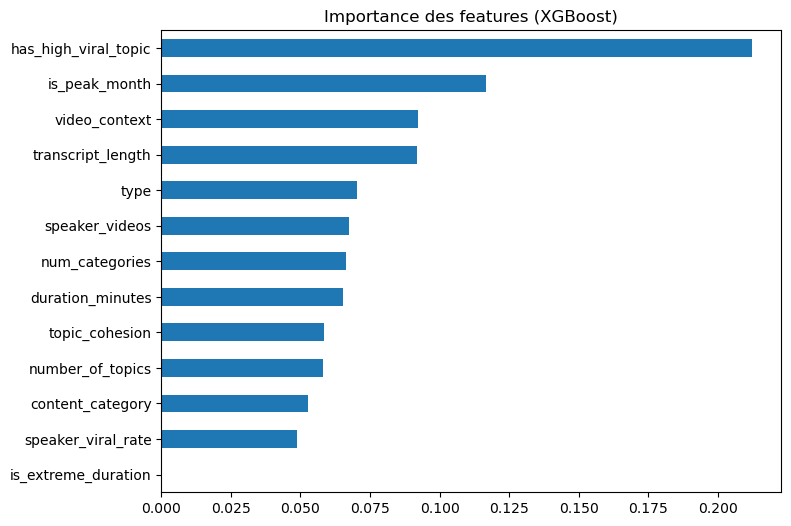

Accuracy baseline: 0.944
Amélioration par rapport à baseline: -0.049


In [140]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Prepare data
df_model = df.copy()
speakers_model = speakers_df.copy()

features_to_drop = ['views', 'popularity_score', 'is_viral_top5', 'days_since_published']
df_model = df_model.drop(columns=[c for c in features_to_drop if c in df_model.columns])
y = df['is_viral'].copy()

# Features
print("2. Extraction des features numériques...")
numeric_features = [
    'duration_minutes', 'number_of_topics', 'transcript_length',
    'topic_cohesion', 'num_categories', 'has_high_viral_topic', 'is_peak_month'
]
X_numeric = df_model[[c for c in numeric_features if c in df_model.columns]].copy()

print("3. Extraction des features catégorielles...")
categorical_features = ['type', 'video_context', 'content_category', 'is_extreme_duration']
X_categorical = pd.DataFrame(index=df_model.index)
for col in [c for c in categorical_features if c in df_model.columns]:
    le = LabelEncoder()
    X_categorical[col] = le.fit_transform(df_model[col].fillna('Unknown'))

print("4. Ajout des features speakers enrichies...")
speaker_features_to_use = ['videos', 'viral_rate']  # skipping wikipedia_numeric as low importance
df_model = df_model.merge(
    speakers_model[['speaker'] + speaker_features_to_use],
    how='left',
    left_on='main_speaker',
    right_on='speaker'
)

# Rename columns
df_model.rename(columns={
    'videos': 'speaker_videos',
    'viral_rate': 'speaker_viral_rate',
}, inplace=True)

# Remplir NaN
for col in ['speaker_videos', 'speaker_viral_rate']:
    df_model[col] = df_model[col].fillna(0)

# Ajouter au X_numeric
for feature in ['speaker_videos','speaker_viral_rate']:
    X_numeric[feature] = df_model[feature]

# Combine features
X = pd.concat([X_numeric, X_categorical], axis=1).fillna(0)
print(f"✓ Shape final: {X.shape}")
print(f"✓ Features utilisées: {list(X.columns)}")

# Split train/test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"  Train: {X_train.shape}, {y_train.mean():.1%} viral")
print(f"  Test:  {X_test.shape}, {y_test.mean():.1%} viral")

# Calcul scale_pos_weight 
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight = {scale_pos_weight:.6f}")

# Training
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5).astype(int)

# Stats
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC XGBoost: {auc:.6f}")

fp = ((y_test==0) & (y_pred==1)).sum()
fn = ((y_test==1) & (y_pred==0)).sum()
tp = ((y_test==1) & (y_pred==1)).sum()
tn = ((y_test==0) & (y_pred==0)).sum()
print(f"FP: {fp} FN: {fn} TP: {tp} TN: {tn}")

print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

# Feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Importance des features (XGBoost)")
plt.show()

# Baseline naïne
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print(f"Accuracy baseline: {baseline_accuracy:.3f}")
print(f"Amélioration par rapport à baseline: {((tp+tn)/len(y_test)) - baseline_accuracy:+.3f}")


In [ ]:


art & design : architecture, art, augmented reality, beauty, conducting, creativity, design, fashion, film, journalism, language, literature, media, museums, music, performance, photogrpahy, poetry, science fiction, sound storytelling, theater, virtual reality, visualizations, writing
business : behavioral economics, blockchain, business, capitalism, consumerism, entrepreneur, investing, manufacturing, marketing, money, women in business
climate change : climate change, driverless cars, electricity, energy, fossil fuels, natural resources, plastic, pollution, renewable energy, sustainability 
communication : Body Language
Collaboration
Communication
Language
Social Media
Public Speaking
Storytelling
visualizations
education : animation, autism spectrum disorder, education, kids, math, museums, teaching, TED-ED, toys, visualizations
entertainment : entertainment, film, gaming, humor, magic, music, performance, television, theatre, toys, travel
global issues : Activism
Ancient World
Anthropology
Global Issues
government 
health care
history
immigration
infrastructure
international developemnt 
military
Policy
Politics
Public Health
Public Space
Religion
Infrastructure
International Development
Military
Sociology
Surveillance
Transportation
War

government & politics : Capitalism
Cities
Community
Corruption
Crime
Democracy
Government|
Health Care
Human Rights
Immigration
Infrastructure
International Development
Justice System
Law
Military
Policy
Politics
Poverty
Public Health
Public Space
Refugees
Terrorism
Transportation
Urban Planning
War

health : Addiction
Aging
Autism Spectrum Disorder
Bacteria
Brain
Cancer
Cognitive Science
Coronavirus
Death
Disability
Disease
Drugs
Exercise
Genetics
Health
Health Care
Human Body
Medicine
Pregnancy
Public Health
Sex
Sleep
Surgery
Transgender


leadership : Communication
Women In Business
Creativity
Goals
Work-Life Balance
Leadership
Motivation
Productivity
Public Speaking
Success

nature : Animals
Bees
Insects
Biodiversity
Birds
Conservation
Coral Reefs
Dinosaurs
Ecology
Fish
Fungi
Nature
Ocean|
Plants
Rivers
Trees
Water
Glaciers 

Parenting : animation, autism spectrum disorder, bullying, education, family, kids, parenting, pregnancy, teaching 

personal growth : Aging
Communication
Compassion
Creativity
Ethics
Fear
Happiness
Love
Mental Health
Trust
Vulnerability
Sex
Curiosity
Death
Depression
Emotions
Empathy
Mindfulness
Motivation
Personal Growth
Sleep

psychology : addiction behavioral economics, brain, compassion, consciousness, creativity, curiosity, depression, emotions, empthy, ethics, fear, happiness, love, memory, mental health, mindfulness, motivation, personality, psychology, violence, vulnerability

relationships : communicaiton, family, friendship, love, relationships, trust 

science : aliens, astronomy, bacteria, cheminstry, dinosaurs, electricity, evolution, life, marine biologyg, mars, moon, physics, planets, science, space, universe

sports & fitness : dance, exercise, food, motivation, sports 
social change : activism, anthropology, disability, diversity, equality, human rights, inclusion, indigenous peoples, lgbtqia+, philanthropy, protest, race, slavery, social change, transgender
technology : 3D printing, ai, blockchain, computers, cyber security, data, driverless cars, drones, engineering, future, internet, nanotechnology, robots, social media, software, surveillance, technology, virtual reality
women : feminism, gender, pregnancy, sexual violence, transgender, women, women in business, work-life balance





SyntaxError: invalid decimal literal (2433521017.py, line 155)